<a href="https://colab.research.google.com/github/SOURAV143-BIT/HEART_FAILURE-PREDICTION-USING-MACHINE-LEARNING/blob/main/heart_failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub
path = kagglehub.dataset_download("andrewmvd/heart-failure-clinical-data")

Using Colab cache for faster access to the 'heart-failure-clinical-data' dataset.


In [ ]:
df=pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [ ]:
## i m gonna predict who gonna get heart failure using random forest cause there r many reasons
# to get a heart failure



/tmp/ipykernel_3176/2059202703.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['age'])


<Axes: xlabel='age', ylabel='Count'>

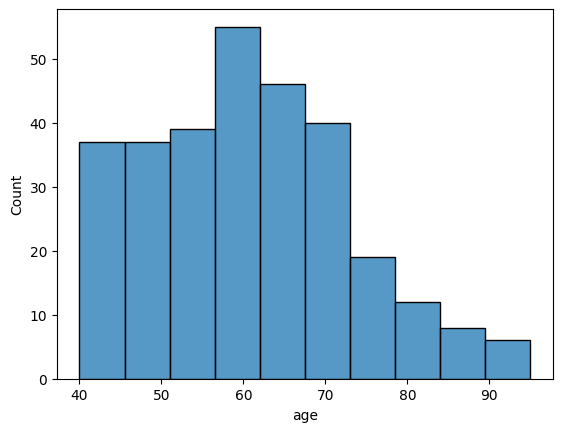

In [ ]:
## first lets see the age of guys we have

pd.value_counts(df['age'])

sns.histplot(df['age'])

In [ ]:
df.info()
## we getting the df information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [ ]:
x=df.drop('DEATH_EVENT',axis=1)
y=df['DEATH_EVENT']

In [ ]:
x

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280


In [ ]:
y

,DEATH_EVENT
0,1
1,1
2,1
3,1
4,1
...,...
294,0
295,0
296,0
297,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)


RandomForestClassifier()

In [ ]:
y_pred=model.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7166666666666667

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[31,  4],
       [13, 12]])

In [ ]:
from sklearn.linear_model import LogisticRegression
model2=LogisticRegression()
model2.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred2=model2.predict(x_test)
y_pred2

array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1])

In [ ]:
from sklearn.metrics import *accuracy_score(y_test,y_pred2)

0.8

In [ ]:
precision_score(y_test,y_pred2)

0.9333333333333333

In [ ]:

recall_score(y_test,y_pred)

0.48

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model3=DecisionTreeClassifier()
model3.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred3=model3.predict(x_test)
y_pred3

array([1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1])

In [ ]:
accuracy_score(y_test,y_pred3)

0.7333333333333333

In [ ]:
## we are getting more accuracy in logistic _Regression with 80%

### Feature Importance from Random Forest Model

Let's examine which features the Random Forest model considered most important in making its predictions. This can give us insights into the key factors related to heart failure.

/tmp/ipykernel_3176/2785846388.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


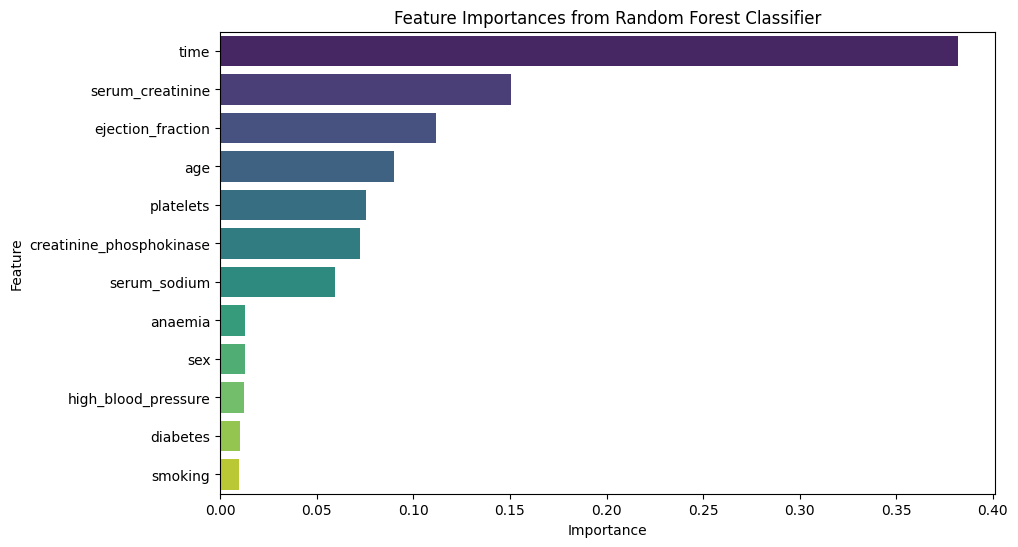

In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=x.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


### Hyperparameter Tuning for Random Forest Classifier

Let's use `GridSearchCV` to find the best hyperparameters for the `RandomForestClassifier`.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           n_jobs=-1, # Use all available CPU cores
                           verbose=2, # Display progress
                           scoring='accuracy') # Metric to optimize

# Fit GridSearchCV to the training data
grid_search.fit(x_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.8955


Now that we have the best parameters, let's train a new Random Forest model with these optimized settings and evaluate its performance on the test set.

In [ ]:
best_rf_model = grid_search.best_estimator_

y_pred_tuned_rf = best_rf_model.predict(x_test)

print(f"Tuned Random Forest Accuracy on Test Set: {accuracy_score(y_test, y_pred_tuned_rf):.4f}")
print("Confusion Matrix for Tuned Random Forest:\n", confusion_matrix(y_test, y_pred_tuned_rf))
print(f"Precision for Tuned Random Forest: {precision_score(y_test, y_pred_tuned_rf):.4f}")
print(f"Recall for Tuned Random Forest: {recall_score(y_test, y_pred_tuned_rf):.4f}")

Tuned Random Forest Accuracy on Test Set: 0.7333
Confusion Matrix for Tuned Random Forest:
 [[32  3]
 [13 12]]
Precision for Tuned Random Forest: 0.8000
Recall for Tuned Random Forest: 0.4800


### Training and Evaluating a Gradient Boosting Classifier

Let's train a `GradientBoostingClassifier` and assess its performance on the test set.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

# Initialize and train the Gradient Boosting Classifier
model_gb = GradientBoostingClassifier(random_state=42)
model_gb.fit(x_train, y_train)

# Make predictions on the test set
y_pred_gb = model_gb.predict(x_test)

# Evaluate the model
print(f"Gradient Boosting Accuracy on Test Set: {accuracy_score(y_test, y_pred_gb):.4f}")
print("Confusion Matrix for Gradient Boosting:\n", confusion_matrix(y_test, y_pred_gb))
print(f"Precision for Gradient Boosting: {precision_score(y_test, y_pred_gb):.4f}")
print(f"Recall for Gradient Boosting: {recall_score(y_test, y_pred_gb):.4f}")

Gradient Boosting Accuracy on Test Set: 0.7167
Confusion Matrix for Gradient Boosting:
 [[31  4]
 [13 12]]
Precision for Gradient Boosting: 0.7500
Recall for Gradient Boosting: 0.4800
